In [33]:
import pandas as pd
import numpy as np  

df_vendas = pd.read_csv("vendas_tech.csv", low_memory="")
display(df_vendas)

df_gerente = pd.read_excel("gerentes_lojas.xlsx")
display(df_gerente)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [34]:
# Tratamento de dados

df_analise = df_vendas.drop(columns=['Data_Base'])

#Tratando valores nulos
df_analise['Loja'] = df_analise['Loja'].fillna('Online')

# Tratando valores com formatações diferentes
df_analise['Loja'] = df_analise['Loja'].str.strip()
df_analise['Loja'] = df_analise['Loja'].str.title()

df_gerente['Loja'] = df_gerente['Loja'].str.strip()
df_gerente['Loja'] = df_gerente['Loja'].str.title()

df_analise['Loja'].unique()

display(df_analise)

df_analise.info()


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545


<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            100100 non-null  str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 5.3 MB


In [35]:
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format= "%Y-%m-%d")

df_analise = df_analise.drop_duplicates(subset=['ID_Pedido'])

display(df_analise)
df_analise.info()



,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


In [36]:
# Criando nova coluna
df_analise['Faturamento'] = df_analise['Qtd'] * df_analise['Preco_Unitario']

# Forma de Venda 
df_analise['Forma_de_Venda'] = np.where(df_analise['Loja'] == 'Online','Online','Presencial')

df_analise['Loja'].unique()

#Regiao + Criação de dicionario

dic_regioes = {
    "São Paulo": "Sudeste",
    "Belo Horizonte": "Sudeste",
    "Rio De Janeiro": "Sudeste",
    "Salvador": "Nordeste",
    "Recife": "Nordeste",
    "Curitiba": "Sul",
    "Porto Alegre": "Sul",
    "Online": "Online"
}


df_analise['Regiao'] = df_analise['Loja'].map(dic_regioes)

display(df_analise)
df_analise.info()


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
 7   Faturamento     100000 non-null  float64       
 8   Forma_de_Venda  100000 non-null  str           
 9   Regiao          100000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 7.6 MB


In [37]:
# Verificando se há valores nulos na tabela
display(df_analise.isna().sum())

ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Regiao            0
dtype: int64

,Loja,Faturamento
6,Salvador,"R$42,300,610.00"
5,Rio De Janeiro,"R$42,294,720.00"
4,Recife,"R$42,190,390.00"
7,São Paulo,"R$42,090,690.00"
0,Belo Horizonte,"R$41,714,890.00"
3,Porto Alegre,"R$41,678,460.00"
1,Curitiba,"R$41,121,720.00"
2,Online,"R$6,080,850.00"


,Produto,Qtd
1,"Monitor 27""",19024
4,Notebook HP,18899
7,iPhone 14,18820
0,Cabo HDMI,18804
6,Teclado Mecânico,18783
2,Mouse Gamer,18771
3,Notebook Dell,18457
5,Smartphone Samsung,18344


,num_mes,Mes,Faturamento
0,1,Jan,25671290.0
1,2,Fev,23181950.0
2,3,Mar,25227580.0
3,4,Abri,24990760.0
4,5,Mai,25772280.0
5,6,Jun,24812470.0
6,7,Jul,25262480.0
7,8,Agost,25753690.0
8,9,Set,24119590.0
9,10,Out,25861060.0


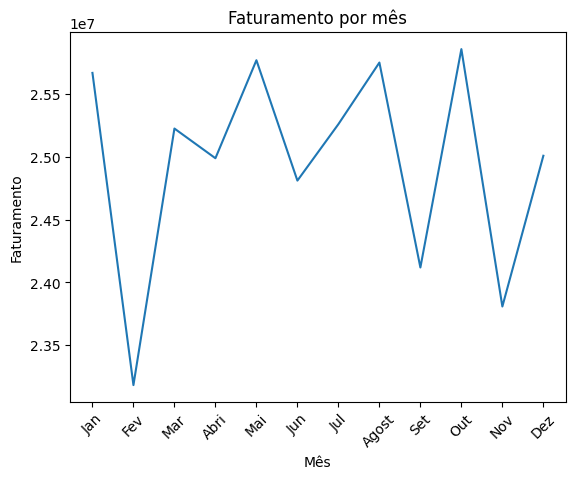

In [ ]:
# Agrupamentos 

# Faturamento por Loja
analise_lojas = df_analise.groupby('Loja')['Faturamento'].sum().reset_index()
analise_lojas = analise_lojas.sort_values(by="Faturamento", ascending=False)
analise_lojas["Faturamento"] = analise_lojas["Faturamento"].map("R${:,.2f}".format)
display(analise_lojas)

# Produto mais vendido

analise_produto = df_analise.groupby("Produto")["Qtd"].sum().reset_index()
analise_produto = analise_produto.sort_values(by="Qtd", ascending= False)
display(analise_produto)


#analise temporal 

df_analise["num_mes"] = df_analise["Data"].dt.month


# Dicionario para trazer o nome dos mêses em Portugues e Ordenados

dic_mes = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abri",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Agost",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez"
}

df_analise["Mes"] = df_analise["num_mes"].map(dic_mes)

analise_temporal = df_analise.groupby(["num_mes","Mes"])["Faturamento"].sum().reset_index()
analise_temporal = analise_temporal.sort_values(by="num_mes")
display(analise_temporal)

# Grafico para analise
import matplotlib.pyplot as plt

plt.figure()
plt.plot(analise_temporal["Mes"].astype(str),analise_temporal["Faturamento"])

plt.title("Faturamento por mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento")

plt.xticks(rotation=45)

plt.show()



In [45]:
#Deletando as colunas Auxliares Mes e num_mes
df_analise = df_analise.drop(columns=["Mes","num_mes"])

# quais Produtos venderam mais em cada loja

analise_produto_loja = df_analise[["Loja","Produto","Qtd"]].groupby(["Loja","Produto"]).sum()
display(analise_produto_loja)

# Quais vendas tiveram o faturamento maior que 11000
df_analise.loc[
    df_analise["Faturamento"] > 11000,
    ["Produto", "Loja","Faturamento"]
].sort_values(by="Faturamento")

Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
...                                 ...
São Paulo      Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

[64 rows x 1 columns]

,Produto,Loja,Faturamento
45147,"Monitor 27""",Porto Alegre,12000.0
35,"Monitor 27""",Rio De Janeiro,12000.0
48938,"Monitor 27""",São Paulo,12000.0
22810,"Monitor 27""",São Paulo,12000.0
22976,"Monitor 27""",Curitiba,12000.0
...,...,...,...
46050,iPhone 14,Rio De Janeiro,55000.0
85852,iPhone 14,São Paulo,55000.0
14565,iPhone 14,Curitiba,55000.0
85189,iPhone 14,Belo Horizonte,55000.0


In [40]:
# Ranking de Produtos que mais venderam online

df_vendas_online = df_analise[df_analise["Loja"] == "Online"]
df_analise_produto_online = df_vendas_online[["Produto","Qtd"]].groupby("Produto").sum().reset_index()
df_analise_produto_online.sort_values(by="Qtd",ascending=False)

# Mudando nome da coluna

df_analise_produto_online = df_analise_produto_online.rename(columns = {"Qtd": "Vendas_Totais"} )
display(df_analise_produto_online)

#Analise de venda de produto por loja

analise_vendas_lojas = df_analise[["Loja","Produto","Qtd"]].groupby(["Loja","Produto"]).sum()
display(analise_vendas_lojas)

# Removendo limite de linhas do resultado 

with pd.option_context("display.max_rows", None):
    display(analise_vendas_lojas)

,Produto,Vendas_Totais
0,Cabo HDMI,403
1,"Monitor 27""",332
2,Mouse Gamer,379
3,Notebook Dell,369
4,Notebook HP,442
5,Smartphone Samsung,311
6,Teclado Mecânico,343
7,iPhone 14,390


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
...                                 ...
São Paulo      Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

[64 rows x 1 columns]

Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

In [41]:
display(df_analise.head())


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao,num_mes,Mes
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste,6,Jun
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste,3,Mar
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online,2,Fev
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste,11,Nov
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste,1,Jan


In [ ]:
# quais gerentes bateram a meta em janeiro de 2023
df_meta = df_analise[(df_analise["Data"].dt.year == 2023) & (df_analise["Data"].dt.month == 1)]
df_meta = df_meta[["Loja","Faturamento"]].groupby("Loja").sum().reset_index().sort_values(by="Faturamento", ascending=False)

df_meta = df_meta.merge(df_gerente, on="Loja", how="left")

df_meta["Bateu meta"] = np.where(df_meta["Faturamento"] >= df_meta["Meta_Mensal"],"Sim","Não")
display(df_meta)

# Exportando apenas as vendas de SP para csv

df_vendas_sp = df_analise[df_analise["Loja"] == "São Paulo"]

df_vendas_sp.to_csv("Vendas_SP.csv", index=False)

# Exportando Vendas Geral
df_analise.to_csv("Vendas_Geral.csv", index=False)




,Loja,Faturamento,Gerente,Meta_Mensal,Bateu meta
0,Curitiba,1986920.0,Roberto,45000.0,Sim
1,São Paulo,1831140.0,Carlos,50000.0,Sim
2,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
3,Recife,1779020.0,Marcos,48000.0,Sim
4,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
5,Porto Alegre,1726640.0,Pedro,42000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,Online,404570.0,NaN,NaN,Não
